# 人工神经网络 ANN (artificial neural network)
## 简称神经网络 NN

## 激活函数：向神经网络中添加非线性元素


### ReLU f(x) = max(0,x)

多应用于隐藏层，且适合深层神经网络
默认情况下只考虑正样本，可以使用LeakeyReLU，PReLU来考虑正负样本

优势：

1.计算量少，训练成本低，收敛速度快

2.使一部分神经元输出为0，造成网络的稀疏性，减少参数相互依存关系，缓解过拟合的发生

缺点：

死亡 ReLU：当 x≤0 时，梯度 = 0，参数完全不更新，导致神经元 “死亡”

梯度爆炸风险（而非步长固定）：如果链式求导中多个 ReLU 梯度都是 1，叠加后梯度可能越来越大，这也是为什么需要学习率衰减、梯度裁剪等策略

### Sigmoid f(x) = 1/(1+e^-x)

主要用于二分类的输出层，适用于浅层神经网络(不超过5层)

数据在[-6,6]之间有效果，在[-3,3]效果明显，将数据映射到[0,1]，求导范围在[0,0.25]

### Tanh f(x) = (e^x-e^-x)/(e^x+e^-x)

主要用于隐藏层，适用于浅层神经网络(不超过5层)

数据在[-3,3]之间有效果，在[-1,1]效果明显，将数据映射到[-1,1]，求导范围在[0,1]

收敛速度快

softmax f(xi) = e^xi/∑j e^xj

适用于多分类，概率和相加为1，选取概率最大的作为结果

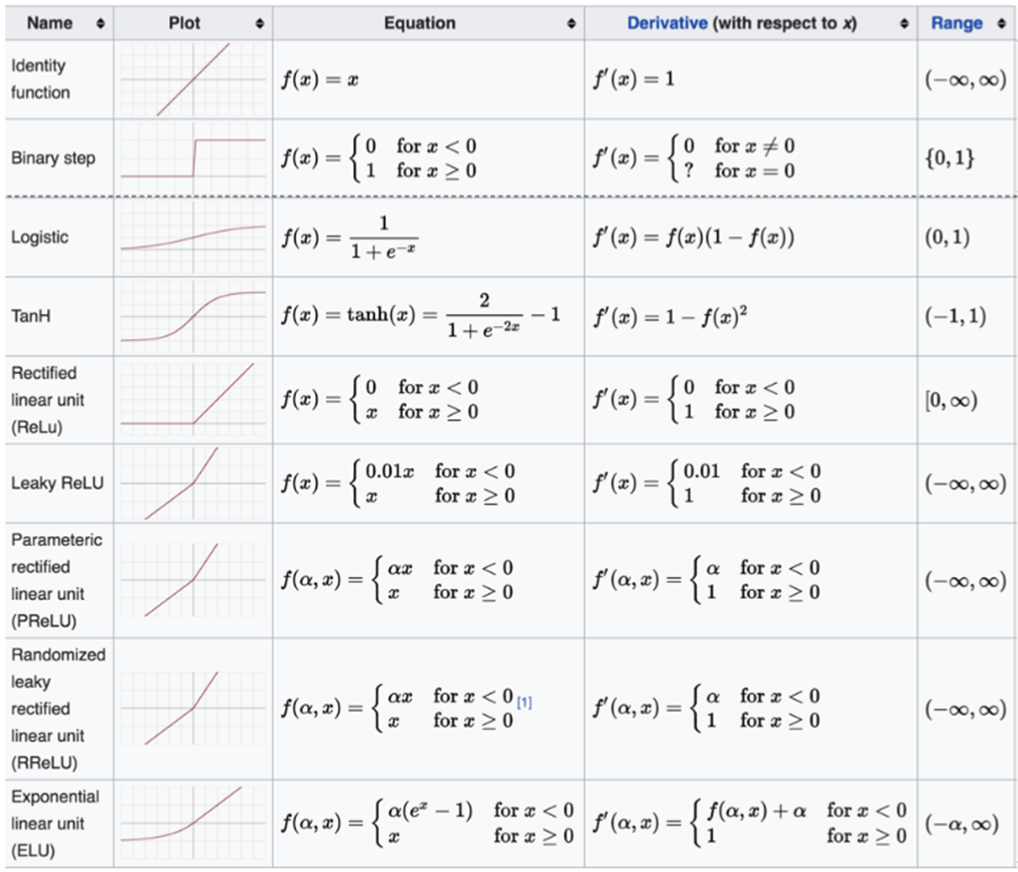

### 对于隐藏层:
优先选择ReLU激活函数

如果ReLu效果不好，那么尝试其他激活，如Leaky ReLu等。

如果你使用了ReLU， 需要注意一下Dead ReLU问题， 避免出现0梯度从而导致过多的神经元死亡。

少用使用sigmoid激活函数，可以尝试使用tanh激活函数

### 对于输出层:
二分类问题选择sigmoid激活函数

多分类问题选择softmax激活函数

回归问题选择identity激活函数
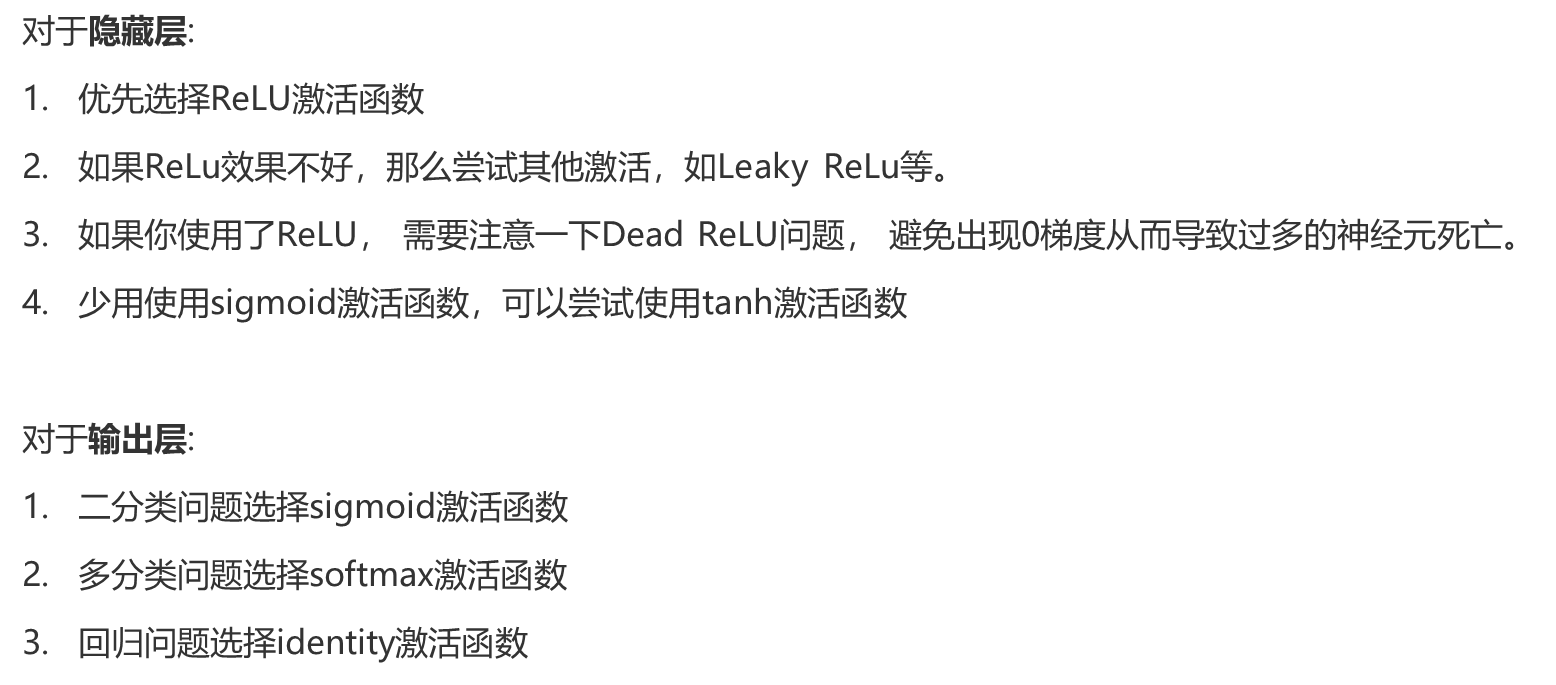
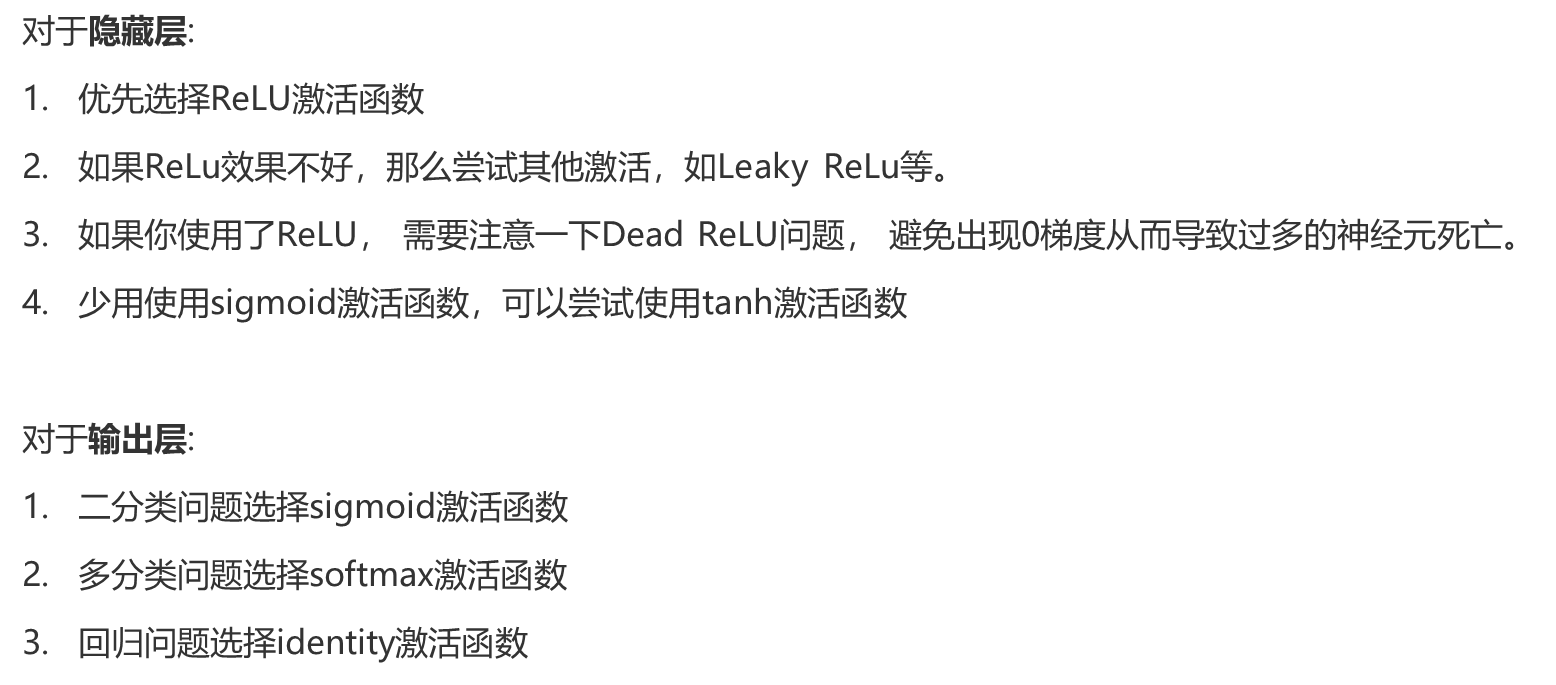
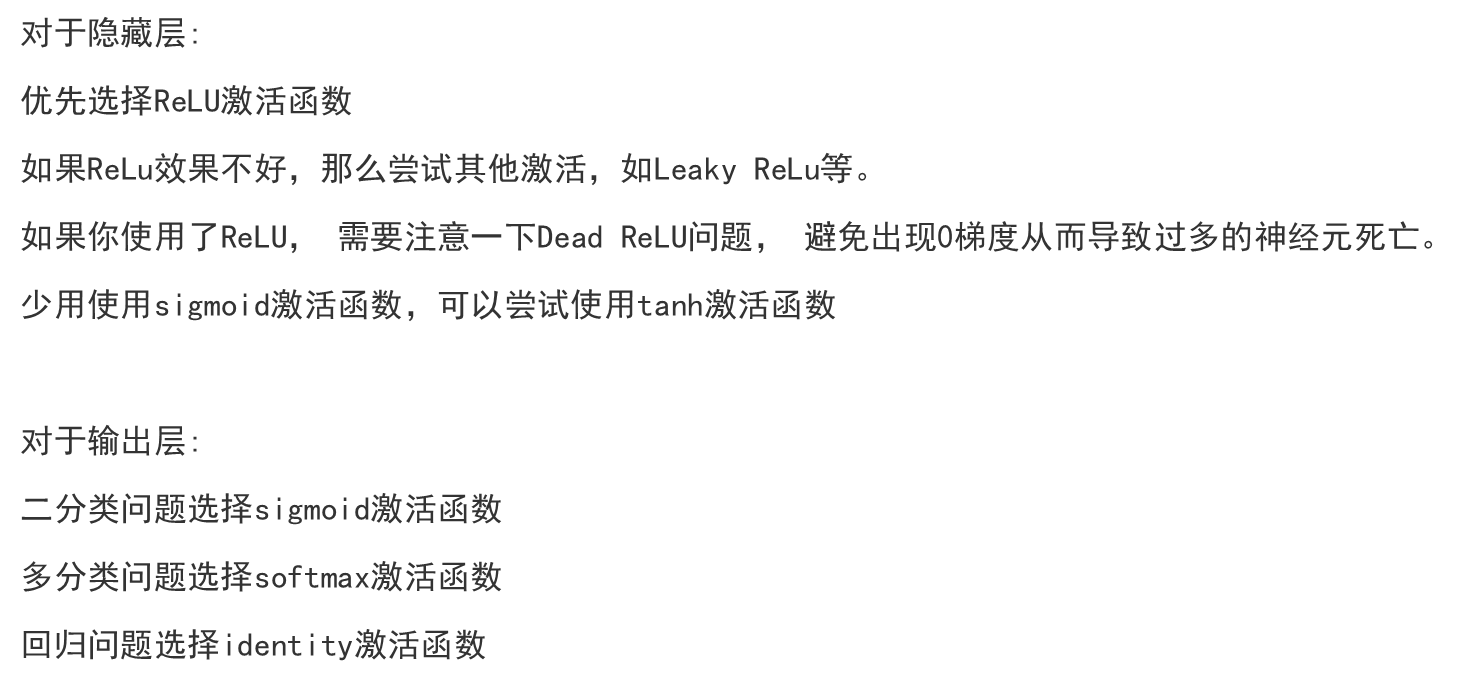
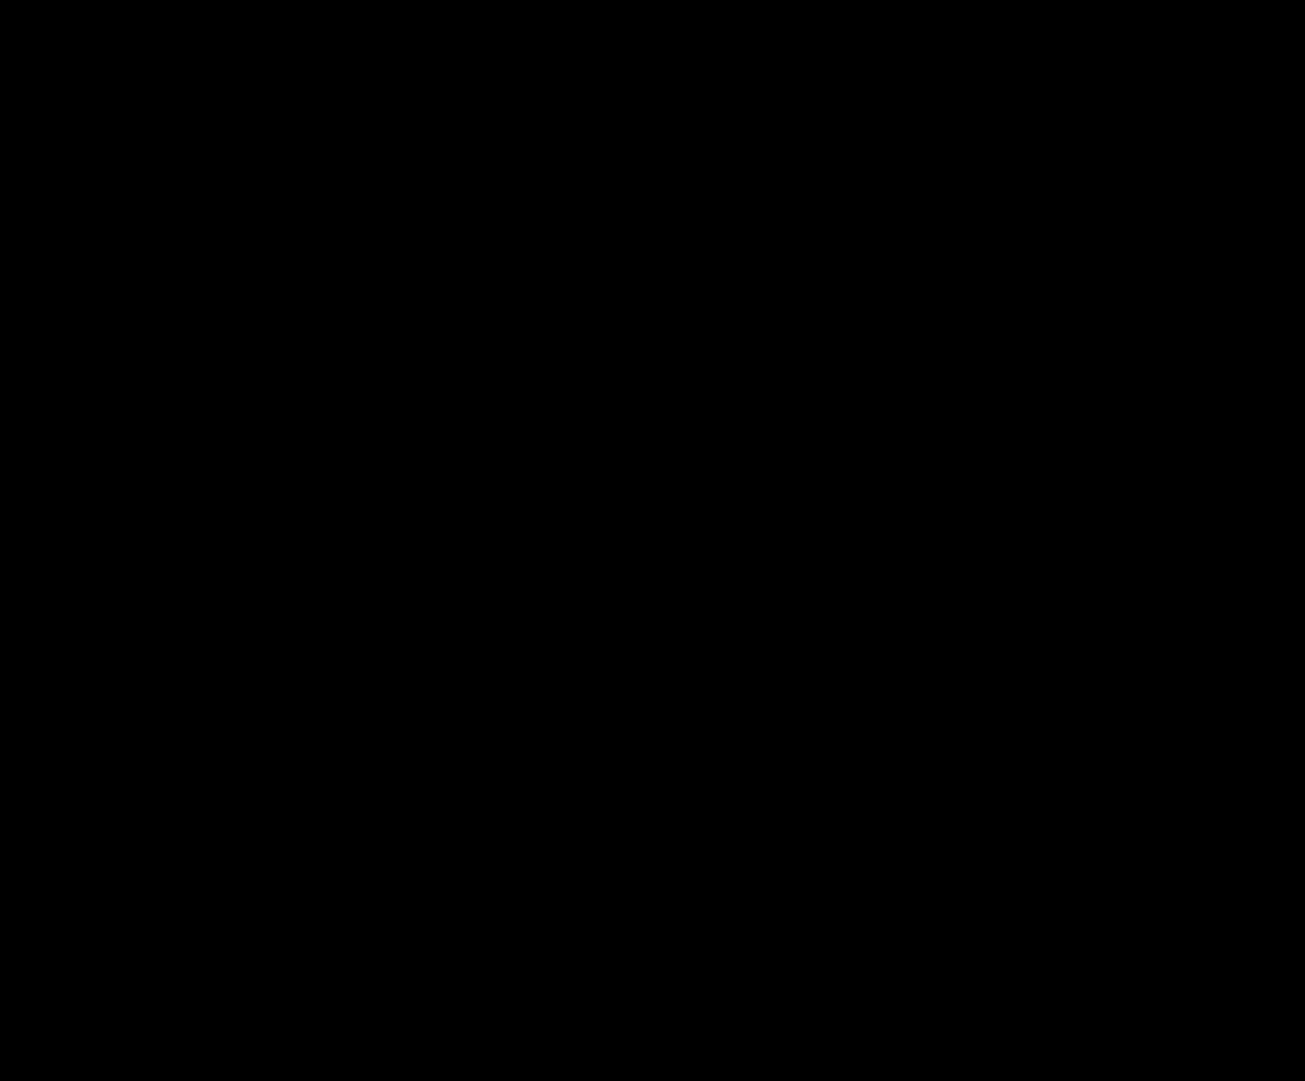
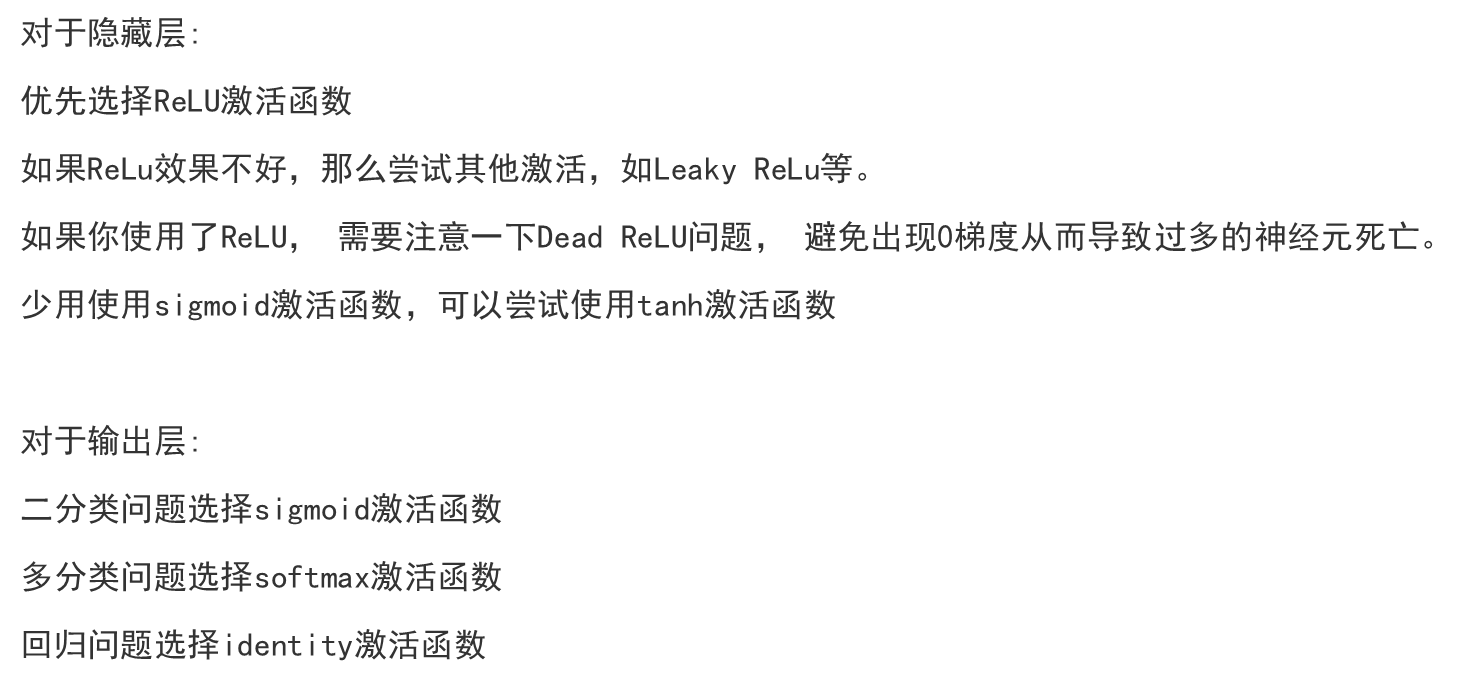

## 参数初始化：防止梯度消失或爆炸，提高收敛速度，破除对称性

### kaiming初始化 (HE初始化) + ReLU

fan_in：上一层的神经元的个数

fan_out：本层的神经元的个数


正态分布的初始化： kaiming_normal_()

从[0, std]抽取样本，其中std = sqrt( 2 / fan_in )

均匀分布的初始化： kaiming_uniform_()

从[-limit, limit]中的均匀分布抽取样本，其中limit = sqrt( 6 / fan_in )

### xavier泽维尔初始化 (Glorot初始化) + Sigmoid、Tanh

正态分布的初始化： xavier_normal_()

从[0, std]抽取样本，其中std = sqrt(2 / (fan_in + fan_out) )

均匀分布的初始化： xavier_uniform_()

从[-limit, limit]中的均匀分布抽取样本，其中limit = sqrt(6 / (fan_in + fan_out) )

### 其余不常用初始化
均匀随机初始化 uniform_()

全0/1初始化 zeros_(),ones_()

固定值初始化 constant_()

正态分布初始化 normal_()

In [9]:
import torch.nn as nn

linear1 = nn.Linear(5,3)
nn.init.normal_(linear1.weight)
nn.init.uniform_(linear1.bias)
print(linear1.weight.data)
print(linear1.bias)
print('-'*30)

linear2 = nn.Linear(5,3)
nn.init.constant_(linear2.weight,3)
nn.init.zeros_(linear2.bias)
print(linear2.weight.data)
print(linear2.bias)
print('-'*30)

linear3 = nn.Linear(5,3)
nn.init.kaiming_uniform_(linear3.weight)
print(linear3.weight.data)
print('-'*30)

tensor([[-1.0968, -0.9635, -0.4137, -0.6150,  0.6401],
        [ 0.2292,  0.2552, -0.7177, -1.0534,  0.1400],
        [ 0.9982, -0.2334,  0.5459,  0.1222,  1.4119]])
Parameter containing:
tensor([0.2761, 0.4597, 0.3767], requires_grad=True)
------------------------------
tensor([[3., 3., 3., 3., 3.],
        [3., 3., 3., 3., 3.],
        [3., 3., 3., 3., 3.]])
Parameter containing:
tensor([0., 0., 0.], requires_grad=True)
------------------------------
tensor([[-0.3456,  0.6458,  0.9816,  0.2332, -0.6972],
        [ 0.9896,  1.0121,  0.4083, -1.0568, -0.0331],
        [-0.3693,  0.5274,  0.6749, -0.5122,  0.2559]])
------------------------------


## 神经网络搭建流程
1. 定义1个类，继承nn.Module
2. 在__init__()方法中搭建神经网络
3. 在forward()方法中完成前向穿播

In [10]:
import torch
import torch.nn as nn
from torchsummary import summary

# todo:1.搭建神经网络
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1 = nn.Linear(3,3)
        self.linear2 = nn.Linear(3,2)
        self.output = nn.Linear(2,2)

        # 对隐藏层进行参数初始化
        nn.init.xavier_uniform_(self.linear1.weight)
        nn.init.zeros_(self.linear1.bias)

        nn.init.kaiming_normal_(self.linear2.weight)
        nn.init.zeros_(self.linear2.bias)

    def forward(self, x):
        x = torch.sigmoid(self.linear1(x))
        x = torch.relu(self.linear2(x))
        x = torch.softmax(self.output(x), dim = 1)     # dim = 1 按行计算
        return x

# todo:2.模型训练
def train():
    net = Net()
    data  = torch.randn(5,3)
    print(f'data: {data}')
    print(f'shape: {data.shape}')      
    print(f'requires_grad: {data.requires_grad}')      

    output = net(data)      # 实例化模型时，底层自动调用forward()进行前向传播
    print(f'output: {output}')
    print(f'shape: {output.shape}')      
    print(f'requires_grad: {output.requires_grad}')
    print('-'*30)

    # 计算和查看模型参数
    print('=' * 10 + '计算模型参数' + '=' * 10)
    summary(net, input_size = (5, 3), device = 'cpu')

    # 查看模型参数
    print('=' * 10 + '查看模型参数' + '=' * 10)
    for name, param in net.named_parameters():
        print(f'name: {name}')
        print(f' param: {param}\n')

if __name__ == '__main__':
    train()

data: tensor([[ 0.8172,  2.0871, -1.0894],
        [-2.0384, -0.1782, -0.1787],
        [-0.2571, -0.6898, -0.8139],
        [-0.0679,  0.5853,  1.0110],
        [-0.9405, -0.3635,  2.2150]])
shape: torch.Size([5, 3])
requires_grad: False
output: tensor([[0.2787, 0.7213],
        [0.2787, 0.7213],
        [0.2787, 0.7213],
        [0.2787, 0.7213],
        [0.2787, 0.7213]], grad_fn=<SoftmaxBackward0>)
shape: torch.Size([5, 2])
requires_grad: True
------------------------------
==========计算模型参数==========
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                 [-1, 5, 3]              12
            Linear-2                 [-1, 5, 2]               8
            Linear-3                 [-1, 5, 2]               6
Total params: 26
Trainable params: 26
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pas

## 损失函数

### 分类问题
#### 1. 多分类交叉熵损失 CrossEntropyLoss()

    loss = -∑ylog(S(f(x))

    注：后续用这个损失函数，那么输出层就不用softmax激活了
样本序号	真实标签 (y_true)	预测得分 (y_pred)（对应 3 个类别的 logits）

第 1 个样本	0（属于第 0 类）	[0.5（第 0 类得分）, 0.8（第 1 类得分）, 0.1（第 2 类得分）]

第 2 个样本	1（属于第 1 类）	[0.7（第 0 类得分）, 0.2（第 1 类得分）, 0.3（第 2 类得分）]

In [11]:
y_true = torch.tensor([[0, 1, 0], [0, 0, 1]],dtype = torch.float)
y_pred = torch.tensor([[0.5, 0.8, 0.1], [0.3, 0.2, 0.7]], requires_grad=True, dtype=torch.float)
criterion = nn.CrossEntropyLoss()
loss = criterion(y_pred, y_true)
print(f'loss: {loss}')

loss: 0.8140546679496765


#### 2. 二分类交叉熵损失 BCELoss()
    loss = -ylogy-(1-y)log(1-y)
    注：公式中不含sigmoid激活函数，使用时输出层还要加上

In [12]:
y_true = torch.tensor([0, 1, 0], dtype = torch.float)
y_pred = torch.tensor([0.6901, 0.5423, 0.2639])
criterion = nn.BCELoss()
loss = criterion(y_pred, y_true)

### 回归问题
#### 1. MAE->L1 Loss() 误差绝对值之和的平均数

       loss = 1/n ∑|y-f(x)|

具有稀疏性：本质是指 L1 正则化的稀疏效应

L1 正则化的损失函数在参数为 0 处有 “尖点”，优化过程中参数更容易收敛到 0（几何上相切于坐标轴，数学上导数固定），而 L2 是平滑的，参数只会趋近于 0

常将其作为正则项添加到其它loss中作为约束

问题：梯度在零点不平滑，会跳过极小值

#### 2. MSE->MSE Loss() 误差平方和的平均数
    loss = 1/n ∑(y-f(x))^2

当预测值和目标值差距很大时，容易梯度爆炸

#### 3. Smooth L1->SmoothL1Loss() 结合MAE和MSE
    loss = 0.5x^2       |x|<1
           |x| - 0.5    else

In [13]:
y_true = torch.tensor([1.0, 2.0, 1.5], dtype = torch.float)
y_pred = torch.tensor([0.5, 0.8, 0.1], dtype = torch.float)
criterion = nn.SmoothL1Loss()
loss = criterion(y_pred, y_true)
print(f'loss: {loss}')

loss: 0.574999988079071
